# In Depth: Principal Component Analysis

PCA is fundamentally a dimensionality reduction algorithm.

Other uses:
- Noise filtering
- Feature exraction and engineering

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
from sklearn.preprocessing import StandardScaler

## Introducing Principal Component Analysis

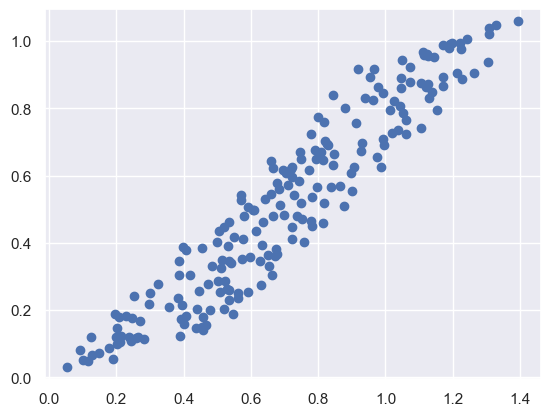

In [3]:
rng = np.random.default_rng(seed=1)
X = np.dot(rng.random((2, 2)), rng.random((2, 200))).T
plt.scatter(X[:, 0], X[:, 1])
plt.axis('equal')
plt.show()

This looks a problem that could be solved with linear regression. But that's not the problem at hand.

Instead of attempting to predict $y$ values from $x$ values, we attempt to find a *relationship* between $x$ and $y$. And unsupervised learning can be used for this.

In Principal component analysis, we can quantify this relationship by finding a list of the **principal axes** in the data, and using these axes the describe the data.

In [4]:
from sklearn.decomposition import PCA
pca_model = PCA(n_components=2)
pca_model.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

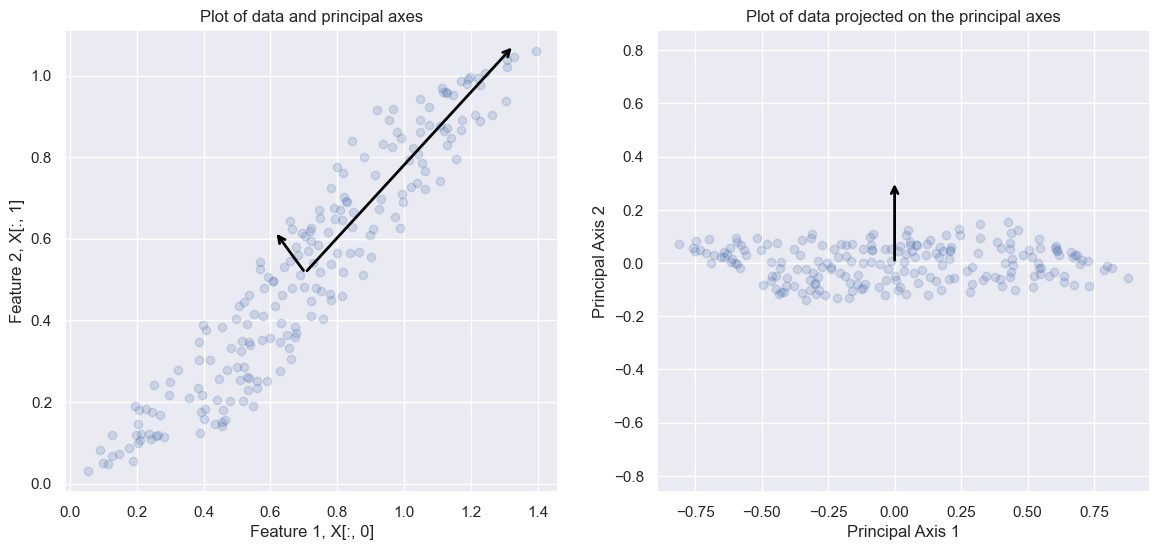

In [5]:
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops = dict(arrowstyle='->',
                     linewidth=2,
                     color = 'black')
    ax.annotate('', v1, v0, arrowprops=arrowprops)

fig, ax = plt.subplots(1,2,figsize=(14,6))
ax[0].scatter(X[:,0], X[:,1], alpha=0.2)
for length, vector in zip(pca_model.explained_variance_, pca_model.components_):
    v = vector * np.sqrt(length) * 2 #Scaled up by 2 so it looks better
    draw_vector(pca_model.mean_, pca_model.mean_ + v, ax=ax[0])
ax[0].set_title('Plot of data and principal axes')
ax[0].set_xlabel('Feature 1, X[:, 0]')
ax[0].set_ylabel('Feature 2, X[:, 1]')

X_transform = pca_model.transform(X)
ax[1].scatter(X_transform[:, 0], X_transform[:, 1], alpha=0.2)
arrowprops = dict(arrowstyle='->', linewidth=2, color='black')
ax[1].annotate('',(0,2 * X_transform[:,1].max()), (0,0), arrowprops=arrowprops)
ax[1].annotate('',(2 * X_transform[:,0].max(),0), (0,0), arrowprops=arrowprops)
ax[1].set_title('Plot of data projected on the principal axes')
ax[1].set_xlabel('Principal Axis 1')
ax[1].set_ylabel('Principal Axis 2')

plt.axis('equal')
plt.show()

- The vectors represent the **principal axes** of the data -- these are the directions along which the features vary the most.
- The length of each vector indicate how the data varies along that direction; conequently, it measures the importance of a feature.
- The projected data are called the **principal components** of the data

We can already see here that the second feature varies. And this is why PCA is a technique for dimensionality reduction -- it makes sense to just drop the second principal component because it has relatively low variance.

### PCA as a dimensionality reduction technique

In [6]:
X_transformed = PCA(n_components=1).fit_transform(X)
print('original shape:', X.shape)
print('transformed shape:', X_transformed.shape)

original shape: (200, 2)
transformed shape: (200, 1)


Once we drop the second component, we can rotate the data back and project it back on the feature space

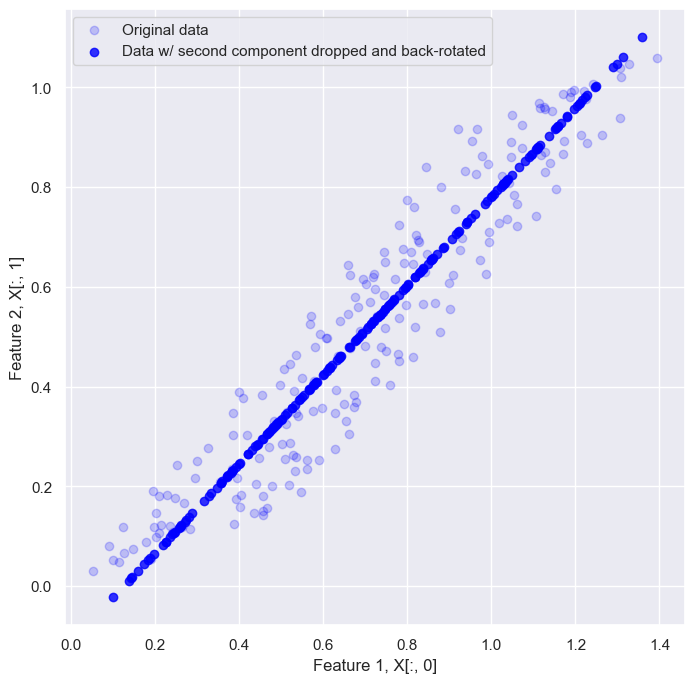

In [7]:
X_new = PCA(n_components=1).fit(X).inverse_transform(X_transformed)
fig = plt.figure(figsize=(8,8))
plt.scatter(X[:,0], X[:,1], alpha=0.2, c='blue', label='Original data')
plt.scatter(X_new[:,0], X_new[:,1], alpha=0.8, c='blue', label='Data w/ second component dropped and back-rotated')
plt.xlabel('Feature 1, X[:, 0]')
plt.ylabel('Feature 2, X[:, 1]')
plt.legend()
plt.show()

PCA as a dimensionality reduction technique means the information along the least important axes is removed, leaving only the components with the highest variance.

### PCA for visualization: Handwritten digits


In [8]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

pca = PCA(n_components=64)
pca.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",64
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

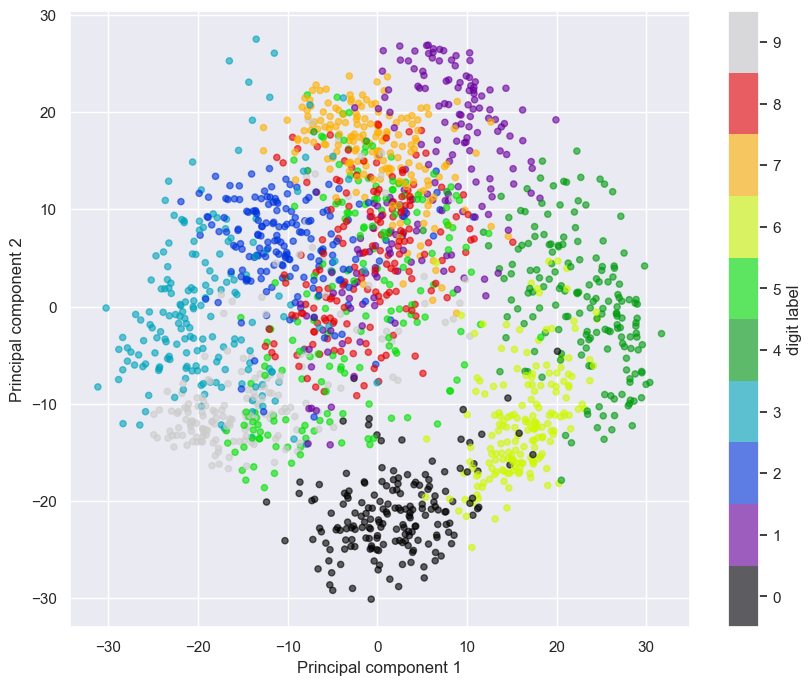

In [9]:
pca = PCA(n_components=2).fit(X)
X_transform = pca.transform(X) #Projected onto the 2 principal components

fig = plt.figure(figsize=(10,8))
plt.scatter(X_transform[:,0], X_transform[:,1], c=y, cmap=plt.get_cmap('nipy_spectral', 10), s=20, alpha=0.6)
plt.colorbar(label='digit label', ticks=range(10))
plt.clim(-0.5,9.5)

plt.xlabel('Principal component 1')
plt.ylabel('Principal component 2')
plt.show()

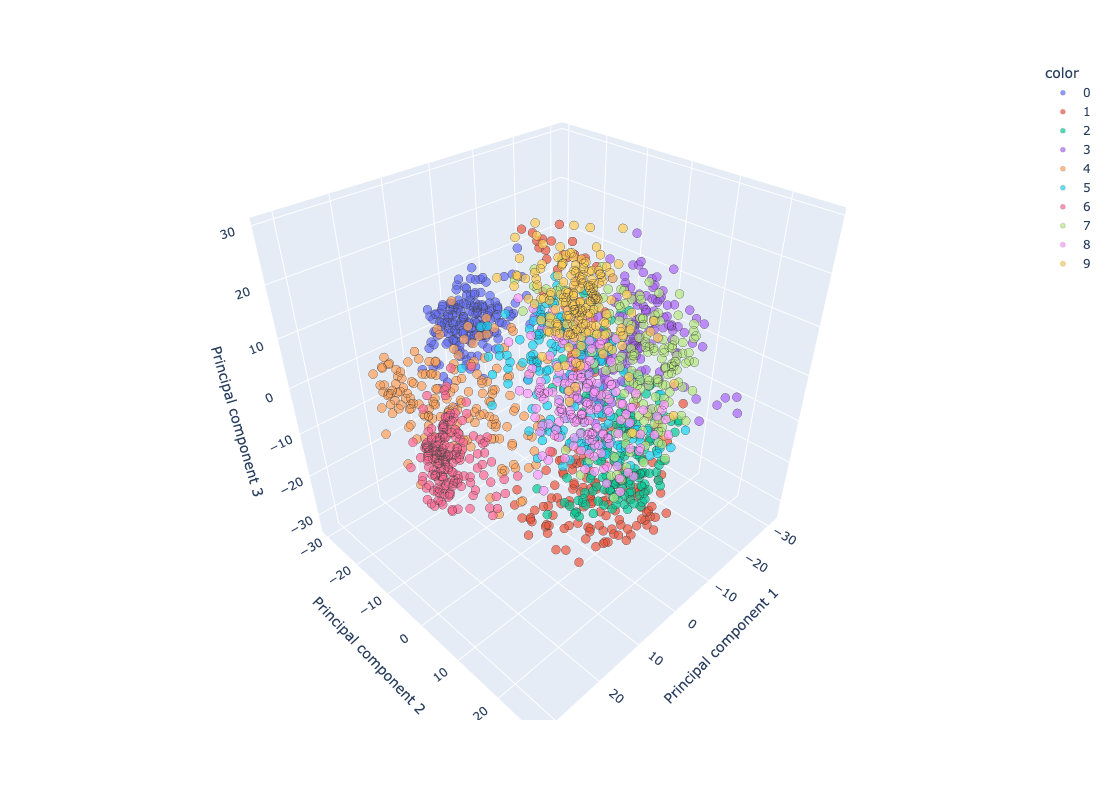

In [10]:
import plotly.express as px

pca = PCA(n_components = 3).fit(X)
X_transform = pca.transform(X)

# Create interactive 3D scatter plot
fig = px.scatter_3d(x=X_transform[:,0], y=X_transform[:,1], z=X_transform[:,2],
                    opacity=0.7, color=y.astype(str), color_discrete_sequence = px.colors.qualitative.Plotly)

fig.update_traces(marker=dict(size=5, line=dict(width=.25)), showlegend=True)
fig.update_layout(coloraxis_showscale=True, width=1000, height=800, scene=dict(
        xaxis=dict(title='Principal component 1'),
        yaxis=dict(title='Principal component 2'),
        zaxis=dict(title='Principal component 3')
    ))

fig.show()


We can see that the 9 types of digits separate quite well in either of these two or three dimensional spaces.

By including the third component, we can see the separation between the 5's and 8's better; but not so much. Quantitatively, including the third component makes a better model as its explained variance is at the same level as the first and second components.

The downside of this technique is that the components are not very easy to interpret. The above 2 and 3 dimensional projections is not the feature space. The components are combinations of features.

### What do the components mean?


In the above image data, an image can be thought of as a linear combination of pixel vectors. So, the value of the j-th feature is the coefficient of pixel j in the linear combination.

$$ \text{image } i = a_{i,0} \cdot (\textbf{pixel }\mathbf{1}) + a_{i,1} \cdot (\textbf{pixel }\mathbf{2}) + \cdots + a_{i,j} \cdot (\textbf{pixel }\mathbf{j}) + \cdots + a_{i,64} \cdot (\textbf{pixel }\mathbf{64})$$

This is just one set of basis vectors to represent an image. PCA can be thought of as finding the optimal set of basis vectors for the data.
For instance, by applying PCA with 8 principal components, we'll get something like

$$ \text{image } i = b_{i,0} \cdot (\textbf{PC }\mathbf{1}) + b_{i,1} \cdot (\textbf{PC }\mathbf{2}) + \cdots + b_{i,j} \cdot (\textbf{PC }\mathbf{j}) + \cdots + b_{i,8} \cdot (\textbf{PC }\mathbf{8})$$

Here, the vectors $\textbf{PC }\mathbf{1},\, \textbf{PC }\mathbf{2},\,\dots,\,\textbf{PC }\mathbf{8}$ are the principal components of the image, and each of these vectors can be represented as the sum of the mean and the linear combinations of the 64 pixels.

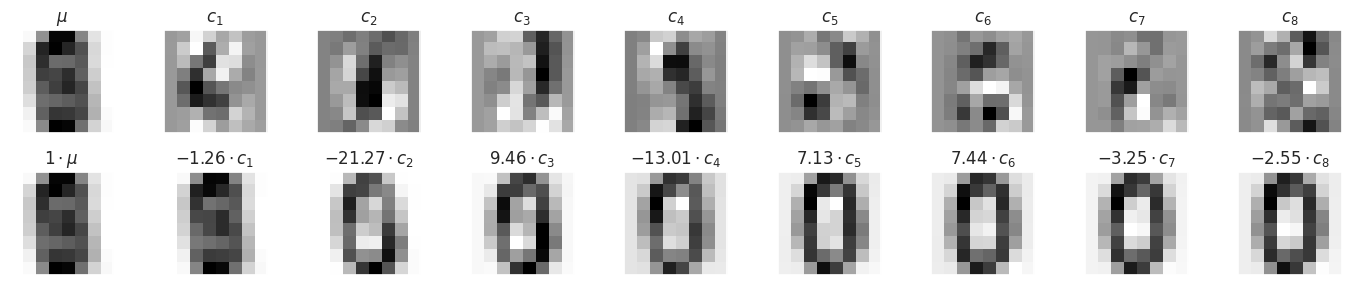

In [11]:
pca = PCA(n_components=8)
pca.fit(X)
X_transform = pca.transform(X)

plt.rcParams['text.usetex'] = False
sample = X_transform[0]
mean = pca.mean_.reshape(8,8)
components = pca.components_.reshape(8,8,8)

fig, ax = plt.subplots(2,9,figsize=(14,3),
                       subplot_kw=dict(xticks=[], yticks=[]))

ax[0,0].imshow(mean, cmap='binary')
ax[0,0].set_title(r'$\mu$')
ax[1,0].imshow(mean, cmap='binary')
ax[1,0].set_title(r'$1\cdot \mu$')

comb = mean
for i, component in enumerate(components):
  comb += sample[i] * component
  ax[0,i+1].imshow(component, cmap='binary')
  ax[0,i+1].set_title(rf"$c_{i+1}$")

  ax[1,i+1].imshow(comb, cmap='binary')
  ax[1,i+1].set_title(rf"${np.round(sample[i],2)} \cdot c_{i+1}$")

fig.tight_layout()
plt.show()

### Choosing the number of components

We can evaluate how many components are needed by looking at the **cumulative explained variance ratio** as a function of `n_components`

In [14]:
X.shape

(1797, 64)

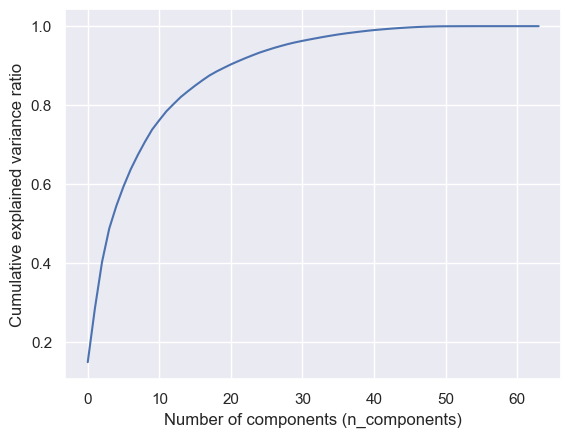

In [23]:
pca = PCA().fit(X)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of components (n_components)')
plt.ylabel('Cumulative explained variance ratio')
plt.show()

The plot tells us the fraction of variance that is preserved for a given number of components to keep.
- Example: If the first 20 components is kept, then 90% of the variance is preserved. In other words, the first 20 components contain 90% of the variance.
- Example: Keeping all components would retain 100% of the variance (obviously)

## PCA as Noise Filtering

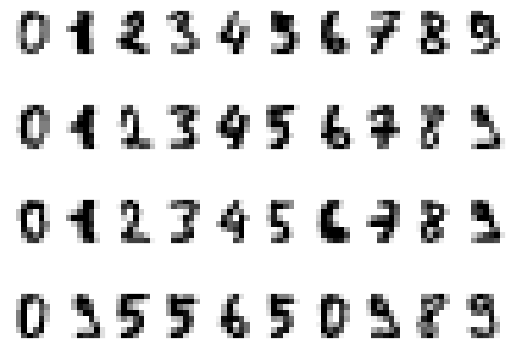

In [12]:
def plot_digits(data):
    fig,ax = plt.subplots(4,10,
                         subplot_kw=dict(xticks=[], yticks=[]),
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))
    for i, ax in enumerate(ax.flat):
        ax.imshow(data[i].reshape(8,8), cmap='binary', interpolation='nearest', clim=(0,16))

plot_digits(digits.data)

Consider the following noisy data

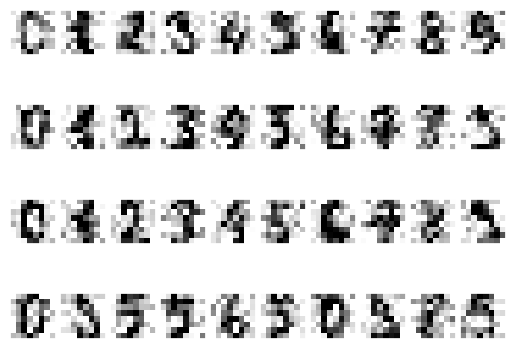

In [13]:
np.random.seed(42)
noisy = np.random.normal(digits.data, 4)
plot_digits(noisy)

PCA can be used for noise filtering by retaining only the first few principal components that contribute a large amount to the variance. By doing this, the signal should be kept while filtering the noise.

By setting `n_components` to take a value between 0 and 1, Sklearn's PCA will select the number of components such that the amount of variance that needs to be explained is greater than the specified fraction.

If I set `n_components=0.5`, PCA will select the number of components whose cumulative explained variance is greater than 50% of the total variance.

n_components: 12
cumulative explained variance ratio:  0.51
Filtered (Denoised) Data:


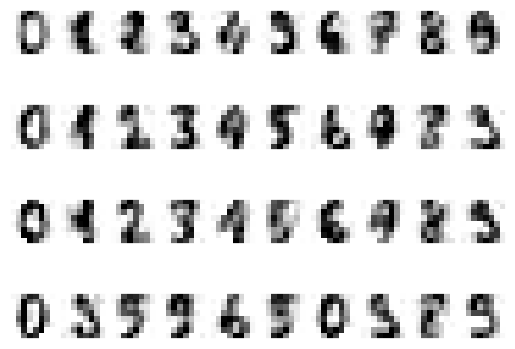

In [28]:
pca = PCA(n_components=0.5).fit(noisy)
noisy_transformed = pca.transform(noisy)
noisy_new = pca.inverse_transform(noisy_transformed)

print('n_components:', pca.components_.shape[0])
print(f'cumulative explained variance ratio: {np.cumsum(pca.explained_variance_ratio_)[-1]: .2f}')

print('Filtered (Denoised) Data:')
plot_digits(noisy_new)

Thus, PCA is useful as a feature selection technique: Rather than training a classifier or regressor on all dimensions of the data, we can use PCA to train on the dimensionality-reduced data and at the same time to filter out random noise.

## Example: Eigenfaces

In [29]:
from sklearn.datasets import fetch_lfw_people
path = '~/IBM-Data-Science-Specialization/Course-9_Machine-Learning/data/Labeled_Faces_in_the_Wild'
faces = fetch_lfw_people(data_home=path,min_faces_per_person=60)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


In [32]:
X = faces.data
X.shape

(1348, 2914)

Here we will use PCA with `n_components = 150`, out of 2914 features, and `svd_solver = 'randomized'` which contains a randomized method to approximate the principal components much more quickly.

In [34]:
pca = PCA(n_components=150, svd_solver='randomized')
pca.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",150
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'randomized'
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomi

The principal components are also called **eigenvectors**. For this data, the principal components are faces, and so we also call them **eigenfaces**

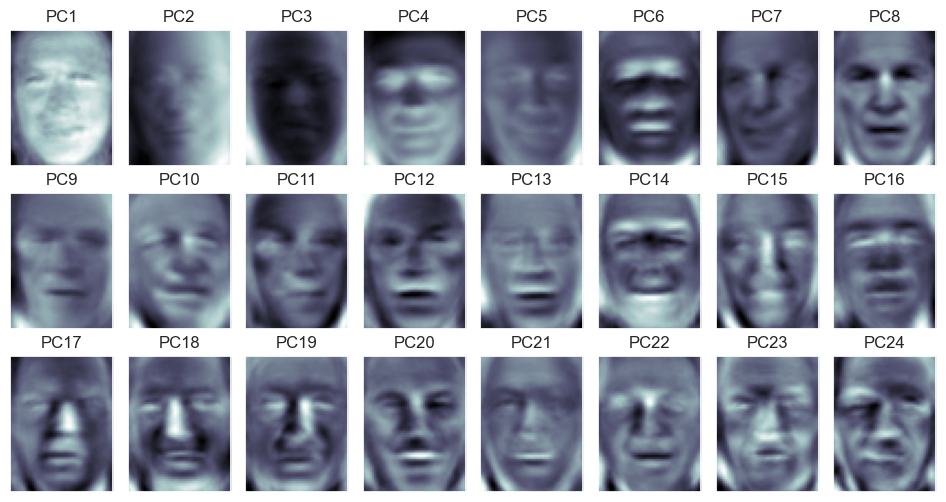

In [43]:
fig, axes = plt.subplots(3, 8, figsize=(12,6), subplot_kw=dict(xticks=[], yticks=[]),
                        gridspec_kw=dict(hspace=0.2, wspace=0.1))

for i,axes in enumerate(axes.flat):
    axes.imshow(pca.components_[i].reshape(62,47), cmap='bone')
    axes.set_title(f'PC{i+1}')

By inspection of the first several principal components:
- The first few eigenfaces seem to be associated with image lighting
- Later principal vectors are associated with facial features such as nose, mouth, eyes, etc.